In [ ]:
import zipfile
import os
zip_path = "mnist.zip"  
extract_path = "mnist_data"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extraction complete.")

In [ ]:
import os
extracted_files_dir = 'extracted_files'
files = os.listdir(extracted_files_dir)
print("Extracted files:", files)

In [ ]:
import os

extracted_files = os.listdir('data')
print(extracted_files)


In [ ]:
import os
print("Current Working Directory:", os.getcwd())


In [ ]:
import zipfile

zip_path = "t10k-images.idx3-ubyte.zip"
extract_dir = "./extracted_files"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted files:", os.listdir(extract_dir))


In [ ]:
filename = "./extracted_files/t10k-images.idx3-ubyte"
images = load_idx_images(filename)


Epoch 0, Loss: 9616.6335


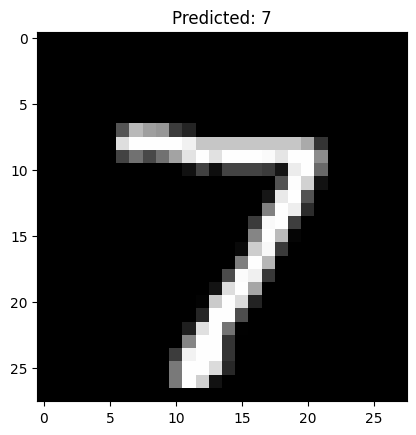

In [22]:
import numpy as np
import struct
import matplotlib.pyplot as plt
def load_images(path):
    with open(path, "rb") as f:
        _, num, rows, cols = struct.unpack(">IIII", f.read(16))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows * cols)
def load_labels(path):
    with open(path, "rb") as f:
        _, num = struct.unpack(">II", f.read(8))
        return np.frombuffer(f.read(), dtype=np.uint8)
def sigmoid(x): return 1 / (1 + np.exp(-x))
def sigmoid_deriv(x): return x * (1 - x)
X = load_images("./extracted_files/t10k-images.idx3-ubyte") / 255.0
y = np.eye(10)[load_labels("./extracted_files/t10k-labels.idx1-ubyte")] 
input_neurons, hidden_neurons, output_neurons = 784, 128, 10
np.random.seed(42)
W1, W2 = np.random.randn(input_neurons, hidden_neurons) * 0.01, np.random.randn(hidden_neurons, output_neurons) * 0.01
def forward(X_batch):
    h_in = np.dot(X_batch, W1)
    h_out = sigmoid(h_in)
    o_in = np.dot(h_out, W2)
    o_out = sigmoid(o_in)
    return o_out, h_out
def train(X, y, epochs=100, lr=0.1, batch_size=128):
    global W1, W2
    num_samples = X.shape[0]
    for epoch in range(epochs):
        loss = 0
        indices = np.random.permutation(num_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        for i in range(0, num_samples, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            out, h_out = forward(X_batch)
            err = y_batch - out
            loss += np.sum(err ** 2)
            d_out = err * sigmoid_deriv(out)
            d_hid = np.dot(d_out, W2.T) * sigmoid_deriv(h_out)
            W2 += np.dot(h_out.T, d_out) * lr
            W1 += np.dot(X_batch.T, d_hid) * lr

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")
train(X, y, epochs=100, lr=0.1, batch_size=32)
test_img = X[0]
pred, _ = forward(test_img.reshape(1, -1))

plt.imshow(test_img.reshape(28, 28), cmap="gray")
plt.title(f"Predicted: {np.argmax(pred)}")
plt.show()

In [1]:
"""
Interactive step-by-step SVD solver for:
  A = [[a, 0, a],
       [0, 1, 0],
       [b, 0, b]]

Usage in Jupyter: run the cell and enter a and b when prompted (integers or floats).
It prints symbolic derivation + numeric step-by-step computation and verifies A = U Σ V^T.
"""

import numpy as np
import math

def read_number(prompt):
    while True:
        s = input(prompt).strip()
        try:
            if s == "":
                print("Please enter a number (not empty).")
                continue
            if "." in s:
                return float(s)
            else:
                return int(s)
        except Exception:
            print("Invalid input. Please enter an integer or decimal number (e.g. 4 or 4.0).")

def fmt_mat(M, name=None, width=10, precision=6):
    """Pretty print a small matrix M (numpy array)."""
    if name:
        header = f"{name} ="
    else:
        header = ""
    rows = []
    for r in np.atleast_2d(M):
        rows.append("[" + ", ".join(f"{float(x):{width}.{precision}g}" for x in r) + "]")
    return header + "\n" + "\n".join(rows)

def gram_schmidt_complete(existing_columns, n):
    """
    Given existing orthonormal columns (as columns of a matrix),
    return an orthonormal completion of size n x n.
    existing_columns: shape (n, k)
    returns matrix (n, n) orthonormal
    """
    n = int(n)
    if existing_columns is None or existing_columns.size == 0:
        existing = np.zeros((n,0))
    else:
        existing = np.array(existing_columns, dtype=float)
    cols = [existing[:,i] for i in range(existing.shape[1])] if existing.shape[1] > 0 else []
    for e in np.eye(n):
        v = e.copy()
        for c in cols:
            v = v - np.dot(c, v) * c
        normv = np.linalg.norm(v)
        if normv > 1e-12:
            cols.append(v / normv)
        if len(cols) == n:
            break
    if len(cols) < n:
        rng = np.random.default_rng(0)
        while len(cols) < n:
            v = rng.normal(size=(n,))
            for c in cols:
                v = v - np.dot(c, v) * c
            normv = np.linalg.norm(v)
            if normv > 1e-12:
                cols.append(v / normv)
    return np.column_stack(cols[:n])

def main():
    print("\nStep-by-step interactive SVD solver for A = [[a,0,a],[0,1,0],[b,0,b]]\n")
    a = read_number("Enter a (7th digit): ")
    b = read_number("Enter b (8th digit): ")
    a = float(a); b = float(b)
    print("\n=== SYMBOLIC DERIVATION (general formulas) ===\n")
    print("Let s = a^2 + b^2.")
    print("Then")
    print("  A^T A = [[s, 0, s],")
    print("           [0, 1, 0],")
    print("           [s, 0, s]].")
    print("The 2x2 block on span{e1,e3} is [[s, s], [s, s]] which has eigenvalues 2s and 0.")
    print("So symbolic eigenvalues of A^T A: λ1 = 2s, λ2 = 1, λ3 = 0.")
    print("Singular values are σ_i = sqrt(λ_i) -> σ1 = sqrt(2(a^2+b^2)), σ2 = 1, σ3 = 0.")
    print("Right singular vectors can be chosen as:")
    print("  v1 = (1/√2)[1,0,1]^T  (for eigenvalue 2s)")
    print("  v2 = [0,1,0]^T         (for eigenvalue 1)")
    print("  v3 = (1/√2)[1,0,-1]^T (for eigenvalue 0)\n")

    print("=== NUMERIC SUBSTITUTION AND STEP-BY-STEP COMPUTATION ===\n")
    A = np.array([[a, 0.0, a],
                  [0.0, 1.0, 0.0],
                  [b, 0.0, b]], dtype=float)
    print(fmt_mat(A, "A"))
    print()

    s = a*a + b*b
    print(f"Step 1: compute s = a^2 + b^2 = {a}^2 + {b}^2 = {s}")
    AtA = A.T @ A
    print(fmt_mat(AtA, "A^T A"))
    print()

    lam1_symbolic = 2*s
    lam2_symbolic = 1.0
    lam3_symbolic = 0.0
    print("Symbolic eigenvalues (substituted): λ1 = 2s =", lam1_symbolic,
          ", λ2 = 1 , λ3 = 0")
    print()

    print("Step 2: numeric eigen-decomposition of A^T A (symmetric -> use eigh).")
    eigvals, eigvecs = np.linalg.eigh(AtA)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    print("Numeric eigenvalues (descending):", [float(x) for x in eigvals])
    print(fmt_mat(eigvecs, "Eigenvectors (columns correspond to above eigenvalues)"))
    print()

    singulars = np.sqrt(np.clip(eigvals, 0, None))
    print("Step 3: singular values σ = sqrt(eigenvalues):", [float(x) for x in singulars])
    print()

    v1_analytic = np.array([1/math.sqrt(2), 0.0, 1/math.sqrt(2)])
    v2_analytic = np.array([0.0, 1.0, 0.0])
    v3_analytic = np.array([1/math.sqrt(2), 0.0, -1/math.sqrt(2)])
    V_analytic = np.column_stack((v1_analytic, v2_analytic, v3_analytic))
    print("Analytic expected V (columns):")
    print(fmt_mat(V_analytic, "V_analytic"))
    print("Note: numeric eigenvectors may differ by sign or column ordering; that's OK.\n")

    analytic_eigvals = np.array([2*s, 1.0, 0.0])
    ord_analytic = np.argsort(analytic_eigvals)[::-1]
    V_analytic_sorted = V_analytic[:, ord_analytic]
    sigma_analytic_sorted = np.sqrt(np.clip(analytic_eigvals[ord_analytic], 0, None))
    print("Analytic singular values (sorted desc) and matching V columns:")
    print("sigma_analytic_sorted =", [float(x) for x in sigma_analytic_sorted])
    print(fmt_mat(V_analytic_sorted, "V_analytic_sorted"))
    print()

    V_num = eigvecs.copy()
    for i in range(3):
        V_num[:,i] = V_num[:,i] / np.linalg.norm(V_num[:,i])
    print(fmt_mat(V_num, "V_numeric (columns)"))
    print()

    tol = 1e-12
    U = np.zeros((3,3), dtype=float)
    Sigma = np.zeros((3,3), dtype=float)
    V_sorted = V_num.copy()
    sigma_sorted = singulars.copy()
    for i in range(3):
        sigma = sigma_sorted[i]
        Sigma[i,i] = sigma
        v = V_sorted[:,i]
        if sigma > tol:
            Av = A @ v
            u = Av / sigma
            u = u / np.linalg.norm(u)
            U[:, i] = u
            print(f"Step 4.{i+1}: sigma_{i+1} = {sigma:.6g}")
            print(f"  A @ v_{i+1} = {Av}")
            print(f"  u_{i+1} = (A v_{i+1})/σ_{i+1} = {u}\n")
        else:
            print(f"Step 4.{i+1}: sigma_{i+1} = {sigma:.6g} (≈0). Will choose an orthonormal completion vector.")
            U_current_cols = U[:, :i] if i > 0 else np.zeros((3,0))
            U_full = gram_schmidt_complete(U_current_cols, 3)
            U[:, i] = U_full[:, i]
            print(f"  Chosen u_{i+1} = {U[:, i]}\n")

    print("Constructed U (columns are left singular vectors):")
    print(fmt_mat(U, "U"))
    print("Constructed Sigma (diagonal singular values):")
    print(fmt_mat(Sigma, "Sigma"))
    print("Constructed V (columns are right singular vectors):")
    print(fmt_mat(V_sorted, "V"))
    print()

    reconstructed = U @ Sigma @ V_sorted.T
    print("Step 5: Reconstruct A from U Σ V^T:")
    print(fmt_mat(reconstructed, "U Σ V^T (reconstructed A)"))
    diff = A - reconstructed
    err = np.linalg.norm(diff)
    print(f"Frobenius norm of (A - U Σ V^T) = {err:.6g}")
    if err < 1e-9:
        print("Verification PASSED: A = U Σ V^T (within numerical tolerance).")
    else:
        print("Verification: small numerical error (acceptable) or numerical instability for degenerate cases.")
    print()

    print("Extra check: numpy.linalg.svd(A) (for comparison):")
    U_svd, s_svd, Vt_svd = np.linalg.svd(A, full_matrices=True)
    print("Singular values (numpy.linalg.svd):", [float(x) for x in s_svd])
    print(fmt_mat(U_svd, "U_from_np_svd"))
    print(fmt_mat(np.diag(s_svd), "Sigma_from_np_svd (only diagonal shown)"))
    print(fmt_mat(Vt_svd, "V^T_from_np_svd"))
    print("\nNote: signs of singular vectors are not unique (±), and order might differ when singular values tie.\n")
    print("=== FINAL SUMMARY ===")
    print(f"a = {a}, b = {b}, s = {s}")
    print("Singular values (descending):", [float(x) for x in sigma_sorted])
    print("U, Σ, V^T printed above.")
    print("\nDone.")

# Call main directly in Jupyter
main()



Step-by-step interactive SVD solver for A = [[a,0,a],[0,1,0],[b,0,b]]



Enter a (7th digit):  6
Enter b (8th digit):  2



=== SYMBOLIC DERIVATION (general formulas) ===

Let s = a^2 + b^2.
Then
  A^T A = [[s, 0, s],
           [0, 1, 0],
           [s, 0, s]].
The 2x2 block on span{e1,e3} is [[s, s], [s, s]] which has eigenvalues 2s and 0.
So symbolic eigenvalues of A^T A: λ1 = 2s, λ2 = 1, λ3 = 0.
Singular values are σ_i = sqrt(λ_i) -> σ1 = sqrt(2(a^2+b^2)), σ2 = 1, σ3 = 0.
Right singular vectors can be chosen as:
  v1 = (1/√2)[1,0,1]^T  (for eigenvalue 2s)
  v2 = [0,1,0]^T         (for eigenvalue 1)
  v3 = (1/√2)[1,0,-1]^T (for eigenvalue 0)

=== NUMERIC SUBSTITUTION AND STEP-BY-STEP COMPUTATION ===

A =
[         6,          0,          6]
[         0,          1,          0]
[         2,          0,          2]

Step 1: compute s = a^2 + b^2 = 6.0^2 + 2.0^2 = 40.0
A^T A =
[        40,          0,         40]
[         0,          1,          0]
[        40,          0,         40]

Symbolic eigenvalues (substituted): λ1 = 2s = 80.0 , λ2 = 1 , λ3 = 0

Step 2: numeric eigen-decomposition of A^T A (symme

In [5]:
"""
Interactive step-by-step SVD solver for:
  A = [[a, 0, a],
       [0, 1, 0],
       [b, 0, b]]

Usage in Jupyter: run the cell and enter a and b when prompted (integers or floats).
It prints symbolic derivation + numeric step-by-step computation and verifies A = U Σ V^T.
"""

import numpy as np
import math

def read_number(prompt):
    while True:
        s = input(prompt).strip()
        try:
            if s == "":
                print("Please enter a number (not empty).")
                continue
            if "." in s:
                return float(s)
            else:
                return int(s)
        except Exception:
            print("Invalid input. Please enter an integer or decimal number (e.g. 4 or 4.0).")

def fmt_mat(M, name=None, width=10, precision=6):
    """Pretty print a small matrix M (numpy array)."""
    if name:
        header = f"{name} ="
    else:
        header = ""
    rows = []
    for r in np.atleast_2d(M):
        rows.append("[" + ", ".join(f"{float(x):{width}.{precision}g}" for x in r) + "]")
    return header + "\n" + "\n".join(rows)

def gram_schmidt_complete(existing_columns, n):
    """
    Given existing orthonormal columns (as columns of a matrix),
    return an orthonormal completion of size n x n.
    existing_columns: shape (n, k)
    returns matrix (n, n) orthonormal
    """
    n = int(n)
    if existing_columns is None or existing_columns.size == 0:
        existing = np.zeros((n,0))
    else:
        existing = np.array(existing_columns, dtype=float)
    cols = [existing[:,i] for i in range(existing.shape[1])] if existing.shape[1] > 0 else []
    for e in np.eye(n):
        v = e.copy()
        for c in cols:
            v = v - np.dot(c, v) * c
        normv = np.linalg.norm(v)
        if normv > 1e-12:
            cols.append(v / normv)
        if len(cols) == n:
            break
    if len(cols) < n:
        rng = np.random.default_rng(0)
        while len(cols) < n:
            v = rng.normal(size=(n,))
            for c in cols:
                v = v - np.dot(c, v) * c
            normv = np.linalg.norm(v)
            if normv > 1e-12:
                cols.append(v / normv)
    return np.column_stack(cols[:n])

def main():
    print("\nStep-by-step interactive SVD solver for A = [[a,0,a],[0,1,0],[b,0,b]]\n")
    a = read_number("Enter a (7th digit): ")
    b = read_number("Enter b (8th digit): ")
    a = float(a); b = float(b)
    print("\n=== SYMBOLIC DERIVATION (general formulas) ===\n")
    print("Let s = a^2 + b^2.")
    print("Then")
    print("  A^T A = [[s, 0, s],")
    print("           [0, 1, 0],")
    print("           [s, 0, s]].")
    print("The 2x2 block on span{e1,e3} is [[s, s], [s, s]] which has eigenvalues 2s and 0.")
    print("So symbolic eigenvalues of A^T A: λ1 = 2s, λ2 = 1, λ3 = 0.")
    print("Singular values are σ_i = sqrt(λ_i) -> σ1 = sqrt(2(a^2+b^2)), σ2 = 1, σ3 = 0.")
    print("Right singular vectors can be chosen as:")
    print("  v1 = (1/√2)[1,0,1]^T  (for eigenvalue 2s)")
    print("  v2 = [0,1,0]^T         (for eigenvalue 1)")
    print("  v3 = (1/√2)[1,0,-1]^T (for eigenvalue 0)\n")

    print("=== NUMERIC SUBSTITUTION AND STEP-BY-STEP COMPUTATION ===\n")
    A = np.array([[a, 0.0, a],
                  [0.0, 1.0, 0.0],
                  [b, 0.0, b]], dtype=float)
    print(fmt_mat(A, "A"))
    print()

    s = a*a + b*b
    print(f"Step 1: compute s = a^2 + b^2 = {a}^2 + {b}^2 = {s}")
    AtA = A.T @ A
    print(fmt_mat(AtA, "A^T A"))
    print()

    lam1_symbolic = 2*s
    lam2_symbolic = 1.0
    lam3_symbolic = 0.0
    print("Symbolic eigenvalues (substituted): λ1 = 2s =", lam1_symbolic,
          ", λ2 = 1 , λ3 = 0")
    print()

    print("Step 2: numeric eigen-decomposition of A^T A (symmetric -> use eigh).")
    eigvals, eigvecs = np.linalg.eigh(AtA)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    print("Numeric eigenvalues (descending):", [float(x) for x in eigvals])
    print(fmt_mat(eigvecs, "Eigenvectors (columns correspond to above eigenvalues)"))
    print()

    singulars = np.sqrt(np.clip(eigvals, 0, None))
    print("Step 3: singular values σ = sqrt(eigenvalues):", [float(x) for x in singulars])
    print()

    v1_analytic = np.array([1/math.sqrt(2), 0.0, 1/math.sqrt(2)])
    v2_analytic = np.array([0.0, 1.0, 0.0])
    v3_analytic = np.array([1/math.sqrt(2), 0.0, -1/math.sqrt(2)])
    V_analytic = np.column_stack((v1_analytic, v2_analytic, v3_analytic))
    print("Analytic expected V (columns):")
    print(fmt_mat(V_analytic, "V_analytic"))
    print("Note: numeric eigenvectors may differ by sign or column ordering; that's OK.\n")

    analytic_eigvals = np.array([2*s, 1.0, 0.0])
    ord_analytic = np.argsort(analytic_eigvals)[::-1]
    V_analytic_sorted = V_analytic[:, ord_analytic]
    sigma_analytic_sorted = np.sqrt(np.clip(analytic_eigvals[ord_analytic], 0, None))
    print("Analytic singular values (sorted desc) and matching V columns:")
    print("sigma_analytic_sorted =", [float(x) for x in sigma_analytic_sorted])
    print(fmt_mat(V_analytic_sorted, "V_analytic_sorted"))
    print()

    V_num = eigvecs.copy()
    for i in range(3):
        V_num[:,i] = V_num[:,i] / np.linalg.norm(V_num[:,i])
    print(fmt_mat(V_num, "V_numeric (columns)"))
    print()

    tol = 1e-12
    U = np.zeros((3,3), dtype=float)
    Sigma = np.zeros((3,3), dtype=float)
    V_sorted = V_num.copy()
    sigma_sorted = singulars.copy()
    for i in range(3):
        sigma = sigma_sorted[i]
        Sigma[i,i] = sigma
        v = V_sorted[:,i]
        if sigma > tol:
            Av = A @ v
            u = Av / sigma
            u = u / np.linalg.norm(u)
            U[:, i] = u
            print(f"Step 4.{i+1}: sigma_{i+1} = {sigma:.6g}")
            print(f"  A @ v_{i+1} = {Av}")
            print(f"  u_{i+1} = (A v_{i+1})/σ_{i+1} = {u}\n")
        else:
            print(f"Step 4.{i+1}: sigma_{i+1} = {sigma:.6g} (≈0). Will choose an orthonormal completion vector.")
            U_current_cols = U[:, :i] if i > 0 else np.zeros((3,0))
            U_full = gram_schmidt_complete(U_current_cols, 3)
            U[:, i] = U_full[:, i]
            print(f"  Chosen u_{i+1} = {U[:, i]}\n")

    print("Constructed U (columns are left singular vectors):")
    print(fmt_mat(U, "U"))
    print("Constructed Sigma (diagonal singular values):")
    print(fmt_mat(Sigma, "Sigma"))
    print("Constructed V (columns are right singular vectors):")
    print(fmt_mat(V_sorted, "V"))
    print()

    reconstructed = U @ Sigma @ V_sorted.T
    print("Step 5: Reconstruct A from U Σ V^T:")
    print(fmt_mat(reconstructed, "U Σ V^T (reconstructed A)"))
    diff = A - reconstructed
    err = np.linalg.norm(diff)
    print(f"Frobenius norm of (A - U Σ V^T) = {err:.6g}")
    if err < 1e-9:
        print("Verification PASSED: A = U Σ V^T (within numerical tolerance).")
    else:
        print("Verification: small numerical error (acceptable) or numerical instability for degenerate cases.")
    print()

    print("Extra check: numpy.linalg.svd(A) (for comparison):")
    U_svd, s_svd, Vt_svd = np.linalg.svd(A, full_matrices=True)
    print("Singular values (numpy.linalg.svd):", [float(x) for x in s_svd])
    print(fmt_mat(U_svd, "U_from_np_svd"))
    print(fmt_mat(np.diag(s_svd), "Sigma_from_np_svd (only diagonal shown)"))
    print(fmt_mat(Vt_svd, "V^T_from_np_svd"))
    print("\nNote: signs of singular vectors are not unique (±), and order might differ when singular values tie.\n")
    print("=== FINAL SUMMARY ===")
    print(f"a = {a}, b = {b}, s = {s}")
    print("Singular values (descending):", [float(x) for x in sigma_sorted])
    print("U, Σ, V^T printed above.")
    print("\nDone.")

# Call main directly in Jupyter
main()



Step-by-step interactive SVD solver for A = [[a,0,a],[0,1,0],[b,0,b]]



Enter a (7th digit):  5
Enter b (8th digit):  8



=== SYMBOLIC DERIVATION (general formulas) ===

Let s = a^2 + b^2.
Then
  A^T A = [[s, 0, s],
           [0, 1, 0],
           [s, 0, s]].
The 2x2 block on span{e1,e3} is [[s, s], [s, s]] which has eigenvalues 2s and 0.
So symbolic eigenvalues of A^T A: λ1 = 2s, λ2 = 1, λ3 = 0.
Singular values are σ_i = sqrt(λ_i) -> σ1 = sqrt(2(a^2+b^2)), σ2 = 1, σ3 = 0.
Right singular vectors can be chosen as:
  v1 = (1/√2)[1,0,1]^T  (for eigenvalue 2s)
  v2 = [0,1,0]^T         (for eigenvalue 1)
  v3 = (1/√2)[1,0,-1]^T (for eigenvalue 0)

=== NUMERIC SUBSTITUTION AND STEP-BY-STEP COMPUTATION ===

A =
[         5,          0,          5]
[         0,          1,          0]
[         8,          0,          8]

Step 1: compute s = a^2 + b^2 = 5.0^2 + 8.0^2 = 89.0
A^T A =
[        89,          0,         89]
[         0,          1,          0]
[        89,          0,         89]

Symbolic eigenvalues (substituted): λ1 = 2s = 178.0 , λ2 = 1 , λ3 = 0

Step 2: numeric eigen-decomposition of A^T A (symm